# Hybrid physics + ML for ocean turbulent mixing (with quadratic bottom drag)

A 1-D wind-driven ocean column in which the trustworthy **dynamical core**
(vertical diffusion of momentum + quadratic bottom drag) is kept exact, and the
uncertain **mixing parameterization** — the eddy viscosity $K$ — is replaced by a
small neural network trained on data. This is the "learned physics" hybrid design
applied to a classic ocean closure: the Richardson-number-dependent vertical mixing
scheme of Pacanowski & Philander (1981), the same family of schemes used in ocean
general circulation models such as MITgcm.

Companion to `01_hybrid_parameterization_pendulum.ipynb` (same idea on a simpler
system); see `docs/parameterization_closure_notes.md` for the underlying theory.

**Requirements:** `numpy`, `scikit-learn`, `matplotlib` — see `requirements.txt`.


In [1]:
# If a package is missing:  pip install -r ../requirements.txt

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor


## 1. The model: a 1-D wind-driven ocean column

A single water column of depth $H$, horizontal velocity $u(z,t)$. Wind stress at the surface
injects momentum; it is mixed downward by turbulence and removed at the seabed by drag:

$$\frac{\partial u}{\partial t}
  = \underbrace{\frac{\partial}{\partial z}\!\Big(K\,\frac{\partial u}{\partial z}\Big)}_{\text{vertical mixing}}
  ,\qquad
  \underbrace{K\frac{\partial u}{\partial z}\Big|_{z=0}=\frac{\tau_s}{\rho}}_{\text{wind stress (top)}}
  ,\qquad
  \underbrace{K\frac{\partial u}{\partial z}\Big|_{z=-H}=C_d\,|u_b|\,u_b}_{\text{quadratic bottom drag}} .$$

**Known, trusted parts (the dynamical core):**
- the vertical-diffusion operator $\partial_z(K\,\partial_z u)$, and
- the **quadratic bottom drag** $\tau_b=\rho\,C_d|u_b|u_b$ (the same $|u|u$ law used in ocean models).

**The unknown to be parameterized (the closure): the eddy viscosity $K$.** Turbulent mixing is
unresolved, so $K$ must be supplied by a scheme. The physically correct behaviour depends on the
**gradient Richardson number** $Ri = N^2 / (\partial u/\partial z)^2$, where $N^2(z)$ is the
background stratification: strong shear with weak stratification (low $Ri$) mixes strongly;
strong stratification (high $Ri$) suppresses mixing. We use a Pacanowski–Philander-type law as
the **truth**:

$$K_\text{true}(Ri)=\nu_b+\frac{\nu_0}{(1+5\,Ri)^2}.$$

$N^2(z)$ has a **thermocline** (a layer of strong stratification) that suppresses mixing there.


In [2]:
# ---- vertical grid (node j=0 at the seabed z=-H, node j=Nz at the surface z=0) ----
H, Nz = 50.0, 50
dz = H / Nz
Nn = Nz + 1
z_node = -H + np.arange(Nn) * dz
z_face = -H + (np.arange(Nz) + 0.5) * dz       # faces between nodes (where K and shear live)

# ---- physical constants ----
C_d      = 2.5e-3          # bottom-drag coefficient
NU_B, NU0 = 2e-3, 0.05     # background and max eddy viscosity (m^2/s)

# stratification: background + a thermocline (mixing-suppressing layer) centred at 18 m depth
N2_face = 1e-5 + 8e-4 * np.exp(-((z_face + 18.0) / 4.0) ** 2)

def K_true_law(S):
    """TRUE eddy viscosity (Pacanowski-Philander form) as a function of shear S=du/dz at faces."""
    Ri = np.clip(N2_face / (S**2 + 1e-12), 0, None)
    return NU_B + NU0 / (1 + 5 * Ri) ** 2


## 2. The shared core solver

`solve_column` integrates the column to steady state with a semi-implicit (backward-Euler)
scheme: the diffusion is implicit (stable at large time steps) and the eddy viscosity is updated
from the current shear each step. The surface wind stress is a flux boundary condition; the
bottom drag is the quadratic law, linearised each step. **Every model below (truth, constant-K,
ML-K) is run through this same solver, so the only thing that changes is how `K` is computed.**


In [3]:
def solve_column(K_of_S, taus_rho, dt=100.0, n_max=6000, tol=1e-9, collect_iters=None):
    """Integrate du/dt = d/dz(K du/dz), wind stress at top, quadratic bottom drag.
       K_of_S(S) returns K at the Nz faces given the shear there.
       Returns u(node), S(face), K(face); if collect_iters is given, also a list of (S,K) snapshots."""
    u = np.zeros(Nn); snaps = []
    for it in range(n_max):
        S = np.diff(u) / dz                         # shear at faces, length Nz
        K = np.clip(K_of_S(S), 1e-5, None)
        if collect_iters and it in collect_iters:
            snaps.append((S.copy(), K.copy()))
        r = C_d * abs(u[0])                          # linearised bottom drag (from previous step)
        A = np.zeros((Nn, Nn)); b = u.copy()
        A[0, 0] = 1 + dt * (r / dz + K[0] / dz**2); A[0, 1] = -dt * K[0] / dz**2   # bottom node
        for j in range(1, Nz):                                                     # interior
            A[j, j-1] = -dt * K[j-1] / dz**2
            A[j, j]   = 1 + dt * (K[j] + K[j-1]) / dz**2
            A[j, j+1] = -dt * K[j] / dz**2
        A[Nz, Nz-1] = -dt * K[Nz-1] / dz**2; A[Nz, Nz] = 1 + dt * K[Nz-1] / dz**2  # surface node
        b[Nz] += dt * taus_rho / dz                                                # wind stress
        u_new = np.linalg.solve(A, b)
        if np.max(np.abs(u_new - u)) < tol:
            u = u_new; break
        u = u_new
    S = np.diff(u) / dz
    K = np.clip(K_of_S(S), 1e-5, None)
    return (u, S, K, snaps) if collect_iters else (u, S, K)


## 3. Generate "high-resolution truth" training data, then learn the closure

We run the *true* column over several wind stresses (and keep a few spin-up snapshots, so the
data spans a range of shears), recording at every face the pair (|shear|, $N^2$) and the true
eddy viscosity $K$. These are the offline training pairs, exactly how a mixing scheme is trained
on high-resolution simulations.

The ML closure learns $K=\text{NN}(|\partial u/\partial z|,\,N^2)$. Because $K$ spans orders of
magnitude (background to fully mixed), we learn $\log K$ so every regime is weighted fairly.


In [4]:
winds_train = np.linspace(0.8e-4, 6e-4, 12)         # range of surface wind stress tau_s/rho
snap_iters  = (5, 15, 40, 100, 300)

S_all, N2_all, K_all, K_steady = [], [], [], []
for tw in winds_train:
    u, S, K, snaps = solve_column(K_true_law, tw, collect_iters=snap_iters)
    K_steady.append(K)                               # steady-state K (for the constant baseline)
    S_all.append(S); N2_all.append(N2_face); K_all.append(K)
    for Ss, Ks in snaps:                             # transient snapshots enrich the shear range
        S_all.append(Ss); N2_all.append(N2_face); K_all.append(Ks)
S_all = np.concatenate(S_all); N2_all = np.concatenate(N2_all); K_all = np.concatenate(K_all)

X = np.column_stack([np.abs(S_all), N2_all])         # features: (|shear|, N^2)
nn_K = TransformedTargetRegressor(
    regressor=make_pipeline(StandardScaler(),
                            MLPRegressor(hidden_layer_sizes=(48, 48), activation="tanh",
                                         solver="lbfgs", max_iter=20000, random_state=0)),
    func=np.log, inverse_func=np.exp)                # learn log K, predict K
nn_K.fit(X, K_all)
print(f"training samples: {X.shape[0]}   NN R^2 on log-K fit = {nn_K.score(X, K_all):.4f}")

# constant-K baseline: the depth-and-wind-averaged true eddy viscosity (a charitable 'best constant')
K_const_val = np.concatenate(K_steady).mean()
print(f"constant-K baseline = {K_const_val:.4f} m^2/s   (true K ranges {K_all.min():.4f}..{K_all.max():.4f})")

def K_ml(S):  # the learned closure, evaluated at the current shear and the column's N^2
    return nn_K.predict(np.column_stack([np.abs(S), N2_face]))


training samples: 3600   NN R^2 on log-K fit = 0.9999
constant-K baseline = 0.0244 m^2/s   (true K ranges 0.0020..0.0410)


## 4. Test on a held-out wind: three closures, one solver

We pick a wind stress not used in training and run three columns that differ only in how $K$ is
set: the **truth** law, a **constant** $K$ (the traditional simplification that ignores the
shear/stratification dependence), and the **ML closure** (the hybrid: trusted core, learned $K$).


In [5]:
taus_test = 2.5e-4
u_true,  _, K_truth = solve_column(K_true_law,                          taus_test)
u_const, _, _       = solve_column(lambda S: np.full_like(S, K_const_val), taus_test)
u_ml,    _, K_mlp   = solve_column(K_ml,                                 taus_test)

rmse_const = np.sqrt(np.mean((u_const - u_true) ** 2))
rmse_ml    = np.sqrt(np.mean((u_ml    - u_true) ** 2))
print(f"held-out wind tau_s/rho = {taus_test} m^2/s^2")
print(f"  surface current: truth {u_true[-1]:.3f}, constant-K {u_const[-1]:.3f}, ML {u_ml[-1]:.3f} m/s")
print(f"  bottom current : truth {u_true[0]:.3f}  (drag balance predicts sqrt(tau/Cd)={np.sqrt(taus_test/C_d):.3f})")
print(f"  RMSE in u(z):  constant-K = {rmse_const:.4f} m/s   |   ML-K = {rmse_ml:.4f} m/s")
print(f"  ML reduces the velocity error by {rmse_const/rmse_ml:.0f}x")


held-out wind tau_s/rho = 0.00025 m^2/s^2
  surface current: truth 1.209, constant-K 0.829, ML 1.206 m/s
  bottom current : truth 0.316  (drag balance predicts sqrt(tau/Cd)=0.316)
  RMSE in u(z):  constant-K = 0.2130 m/s   |   ML-K = 0.0017 m/s
  ML reduces the velocity error by 128x


## 5. The velocity profile and the learned mixing

**Left:** the steady current $u(z)$. Constant-$K$ gets the surface current and the shear
structure wrong; the ML hybrid tracks the truth (note the stronger shear inside the grey
thermocline band, where mixing is suppressed). **Right:** the parameterization itself, the eddy
viscosity as a function of the Richardson number. The true law saturates at low $Ri$ (strong
shear, full mixing) and is suppressed at high $Ri$ (strong stratification); the learned NN
reproduces this stability function across the data.


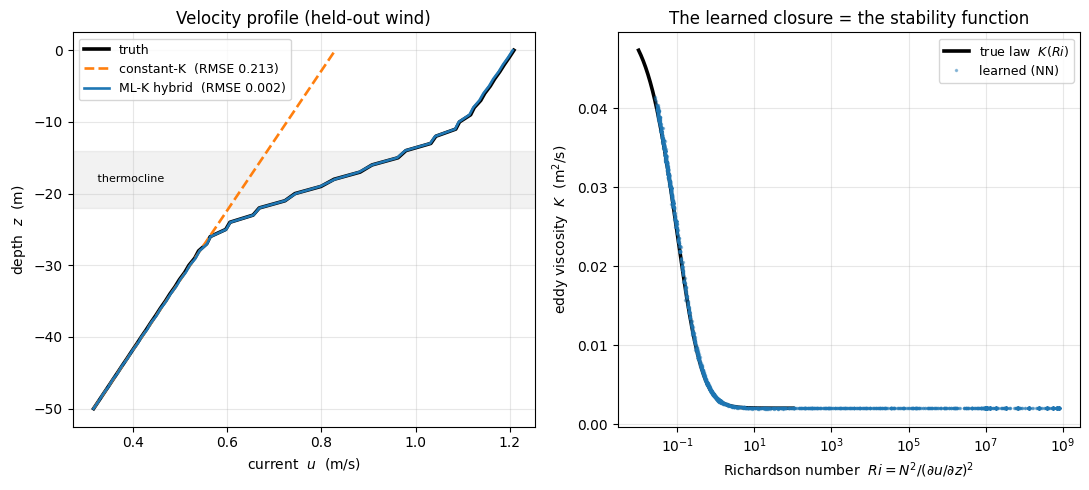

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5.0))

# left: velocity profile vs depth
ax[0].axhspan(-22, -14, color="grey", alpha=0.10)
ax[0].plot(u_true,  z_node, "k",  lw=2.6, label="truth")
ax[0].plot(u_const, z_node, "C1", ls="--", lw=1.9, label=f"constant-K  (RMSE {rmse_const:.3f})")
ax[0].plot(u_ml,    z_node, "C0", ls="-",  lw=1.9, label=f"ML-K hybrid  (RMSE {rmse_ml:.3f})")
ax[0].text(u_true.min(), -18, " thermocline", fontsize=8, va="center")
ax[0].set_xlabel("current  $u$  (m/s)"); ax[0].set_ylabel("depth  $z$  (m)")
ax[0].set_title("Velocity profile (held-out wind)"); ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

# right: the closure itself, K as a function of Richardson number
Ri_grid = np.logspace(-2, 2, 200)
ax[1].plot(Ri_grid, NU_B + NU0 / (1 + 5 * Ri_grid) ** 2, "k", lw=2.6, label="true law  $K(Ri)$")
Ri_tr = N2_all / (S_all**2 + 1e-12)
o = np.argsort(Ri_tr)
ax[1].plot(Ri_tr[o], nn_K.predict(X)[o], "C0", marker=".", ms=3, lw=0, alpha=0.4, label="learned (NN)")
ax[1].set_xscale("log")
ax[1].set_xlabel(r"Richardson number  $Ri=N^2/(\partial u/\partial z)^2$")
ax[1].set_ylabel(r"eddy viscosity  $K$  (m$^2$/s)")
ax[1].set_title("The learned closure = the stability function")
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3, which="both")

fig.tight_layout()
plt.show()


## 6. Generalization: the closure transfers across forcings

An ML parameterization is a function of the **local state** ($|shear|$, $N^2$), not of the wind.
So a single trained closure should work at wind stresses it never saw. We check several held-out
winds (the strongest is outside the training range, i.e. extrapolation):


In [7]:
print(f"{'wind tau_s/rho':>16}{'constant-K RMSE':>18}{'ML-K RMSE':>12}{'improvement':>14}")
print("-" * 60)
for tw in [1.5e-4, 3.5e-4, 5.0e-4, 8.0e-4]:
    ut, _, _ = solve_column(K_true_law, tw)
    uc, _, _ = solve_column(lambda S: np.full_like(S, K_const_val), tw)
    um, _, _ = solve_column(K_ml, tw)
    rc = np.sqrt(np.mean((uc - ut) ** 2)); rm = np.sqrt(np.mean((um - ut) ** 2))
    tag = "  (extrapolation)" if tw > winds_train.max() else ""
    print(f"{tw:>16.1e}{rc:>18.4f}{rm:>12.4f}{rc/rm:>11.0f}x{tag}")


  wind tau_s/rho   constant-K RMSE   ML-K RMSE   improvement
------------------------------------------------------------


         1.5e-04            0.2736      0.0035         79x


         3.5e-04            0.1957      0.0010        192x


         5.0e-04            0.1680      0.0033         51x


         8.0e-04            0.1718      0.0142         12x  (extrapolation)


## 7. Takeaways

- The **dynamical core** (vertical diffusion + quadratic **bottom drag**) is kept exact. Only the
  **turbulent-mixing closure** (the eddy viscosity $K$) is learned — the "learned physics"
  hybrid design.
- A **constant** $K$ (ignoring the shear/stratification dependence) gets the current profile
  badly wrong, because real mixing is suppressed in the thermocline and strong in the mixed
  layers. The **ML closure** recovers the depth-varying $K$ and cuts the velocity error by
  one to two orders of magnitude.
- The learned closure is a function of the **local state**, so it **transfers to wind stresses it
  never saw**, including extrapolation. That portability is the central reason ML
  parameterizations are attractive for ocean and climate models.
- Practical detail that mattered: learn **$\log K$** (and use the L-BFGS solver), because $K$
  spans orders of magnitude; learning $K$ directly lets the large values dominate and fits the
  important small (thermocline) values poorly.

**Natural extensions**
- Add the **Coriolis force** (a $v$-equation) to turn this into a wind-driven **Ekman spiral**,
  and learn the mixing that sets the Ekman-layer depth.
- Swap the Pacanowski–Philander truth for a **KPP**-style boundary-layer scheme
  (Large et al. 1994).
- Move from offline to **online / differentiable training** (embed the NN closure inside the
  solver and train end-to-end).


## References

- Pacanowski, R. C., & Philander, S. G. H. (1981). Parameterization of vertical mixing in
  numerical models of tropical oceans. *Journal of Physical Oceanography*, 11(11), 1443–1451.
- Large, W. G., McWilliams, J. C., & Doney, S. C. (1994). Oceanic vertical mixing: a review
  and a model with a nonlocal boundary layer parameterization. *Reviews of Geophysics*,
  32(4), 363–403.
- Bolton, T., & Zanna, L. (2019). Applications of deep learning to ocean data inference and
  subgrid parameterization. *JAMES*, 11(1), 376–399.
- Zanna, L., & Bolton, T. (2020). Data-driven equation discovery of ocean mesoscale closures.
  *Geophysical Research Letters*, 47(17), e2020GL088376.
- Sane, A., et al. (2023). Parameterizing vertical mixing coefficients in the ocean surface
  boundary layer using neural networks. *JAMES*, 15, e2023MS003890.
